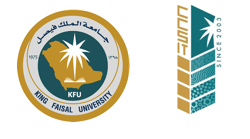

<h3><center>
King Faisal University <br>
College of Computer Sciences and Information Technology <br>
CS412: Data Science <br>
Course Project <br><br>   
</h3>
<h1><center>
Video Game Sales  
</h1>



| **Student name** | **Student ID** | **Section** |
|--------------|-----------------|---------------|
| **Fatimah Nasser Albesher** | 222411640 | 82 |
| **Fatimah Hussain Alabdellah** |222412119 | 82 |
| **Norah Saleh Almarri** | 222411213 | 82 |
| **Atekah Aljafar** | 222427138| 82 |

#  📄 Introduction

This data science project focuses on analyzing and predicting global video game sales using the “Video Game Sales with Ratings” dataset.

**The problem addressed in this project** is understand the key factors that influence video game sales across different markets.

## 🎯 Objectives

1️⃣ Clean and preprocess missing and inconsistent data.

2️⃣ Analyze key sales factors.

3️⃣ Identify sales trends by region.

4️⃣ Present clear insights.

## 🔍 Insights

This project aims to identify which factors most strongly influence `Global_Sales`, understand how sales differ across platforms and genres. These insights will reveal the key drivers behind top-selling video games.

# 📌 Dataset Selection and Description

The dataset sourced from Kaggle contains over 16,000 video game records with detailed information on platforms, genres, publishers, release years, critic and user ratings, regional and global sales. It provides a rich foundation for analyzing market performance and sales patterns. However, it presents challenges, including substantial missing values in key variables and a temporal cutoff at 2016, which limits its reflection of recent industry developments.

# 💻 Exploratory Data Analysis

###  📌 Libraries

In [1]:
import pandas as pd
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn   
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind

###  📌 Load Dataset

In [2]:
# Read the CSV file into a DataFrame.
# df_raw will be kept unchanged for comparison plots.

file_path = "Video_Games_Sales_as_at_22_Dec_2016.csv"
df_raw = pd.read_csv(file_path)

###  📌 Inspect the Data

In [3]:
df_raw.head()       # Shows the first 5 rows of the DataFrame

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


### ✔ What we learn

1- Year_of_Release = 2006.0 (float) -> Should be integer year, not float

2- Critic columns sometimes NaN -> Missing for older games 

3- Rating sometimes NaN -> Not all games have ESRB ratings

In [4]:
df_raw.info()       # Gives a summary of the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


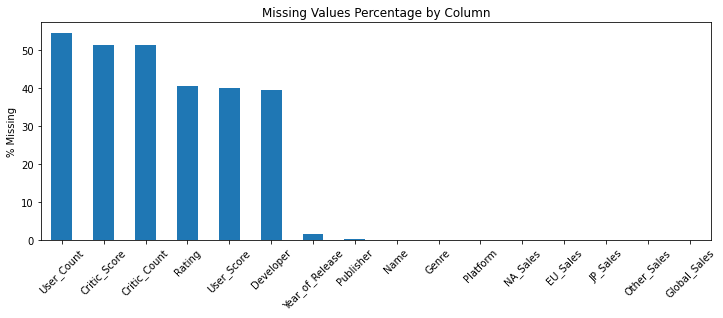

In [5]:
missing_percent = df_raw.isna().mean() * 100
missing_percent.sort_values(ascending=False).plot(kind='bar', figsize=(12,4))
plt.title("Missing Values Percentage by Column")
plt.ylabel("% Missing")
plt.xticks(rotation=45)
plt.show()

In [6]:
df_raw.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

### ✔ What we learn

**1- Several columns have extremely high missingness:**

- Critic_Score & Critic_Count: ~ 8582 missing (~51%)

- User_Score: ~ 6704 missing (~40%), incorrect dtype (object)

- User_Count: ~ 9129 missing (~55%)

- Rating & Developer: ~ 40% missing each

- **➡️(Dropping these columns will remove 50%+ of the dataset)**

**2- Year_of_Release is stored as float -> Should be converted to integer (e.g., 2006.0 -> 2006)**

**3- Sales columns are fully complete -> Clean and ready for EDA**

**4- Only two rows missing Name and Genre -> Safe to drop**

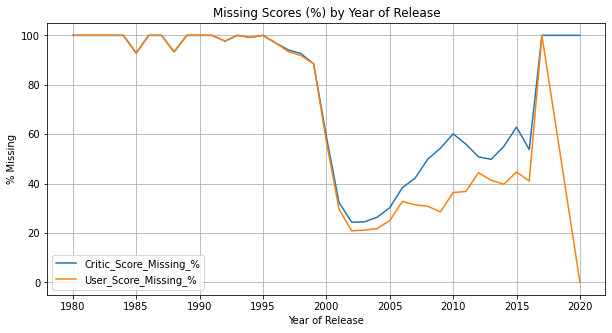

In [7]:
# Create a copy to avoid modifying the original
df_temp = df_raw.copy()

# For each year, calculate % missing critic/user scores
missing_by_year = pd.DataFrame({
    'Critic_Score_Missing_%': df_temp.groupby('Year_of_Release')['Critic_Score'].apply(lambda x: x.isna().mean() * 100),
    'User_Score_Missing_%': df_temp.groupby('Year_of_Release')['User_Score'].apply(lambda x: x.isna().mean() * 100)
})

missing_by_year.plot(figsize=(10, 5))
plt.title("Missing Scores (%) by Year of Release")
plt.ylabel("% Missing")
plt.xlabel("Year of Release")
plt.grid(True)
plt.show()


**💡 The missingness pattern in Critic_Score and User_Score is not random.**

As shown in the “Missing Scores (%) by Year of Release” plot, games released before ~1999 have almost 100% missing scores, because review aggregation websites did not exist. Missingness decreases sharply after the early 2000s, stabilizing in modern years.

This means missing values depend on the release year (Missing Not At Random – MNAR).
Therefore, rows with missing scores should not be dropped or imputed using simple statistics, as it would distort historical comparisons and remove most older games.

In [8]:
df_raw.describe(include='all')

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
count,16717,16719,16450.000000,16717,16665,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,10015,7590.000000,10096,9950
unique,11562,31,NaN,12,581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96,NaN,1696,8
top,Need for Speed: Most Wanted,PS2,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tbd,NaN,Ubisoft,E
freq,12,2161,NaN,3370,1356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2425,NaN,204,3991
mean,NaN,NaN,2006.487356,NaN,NaN,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,NaN,162.229908,NaN,NaN
std,NaN,NaN,5.878995,NaN,NaN,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,NaN,561.282326,NaN,NaN
min,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,NaN,4.000000,NaN,NaN
25%,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,NaN,10.000000,NaN,NaN
50%,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,NaN,24.000000,NaN,NaN
75%,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,NaN,81.000000,NaN,NaN


### ✔ What we learn

1- "tbd" is the most frequent value in User_Score -> wrong dtype.

2- User_Score column is object, not numeric -> convert column to numeric (float).

3- Year_of_Release is float -> Should be an integer year.

4- Year_of_Release has invalid years (2020) -> 2020 is impossible (dataset stops in 2016).

5- Sales are extremely skewed (Max Global_Sales = 82.53M, Median = only 0.17M) -> explain it in EDA


###  📊 EDA code

In [9]:
# We will start With a Clean Copy of the Dataset
df = df_raw.copy()

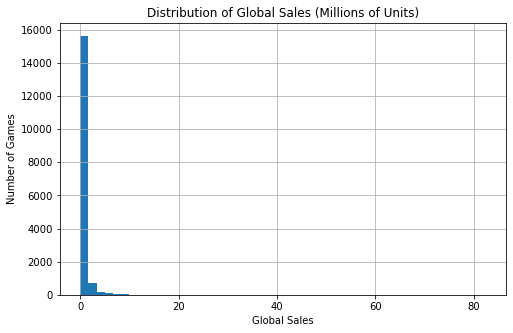

In [10]:
# Distribution of Global Sales

plt.figure(figsize=(8,5))
df['Global_Sales'].hist(bins=50)
plt.title("Distribution of Global Sales (Millions of Units)")
plt.xlabel("Global Sales")
plt.ylabel("Number of Games")
plt.show()

📊 Most games sell very little, and only a few sell extremely large amounts -> This makes the sales distribution highly skewed (long right tail).

⭐ What You Need to Do? Use a log transformation of Global_Sales (extra column) -> This will make patterns clearer and improve model performance.

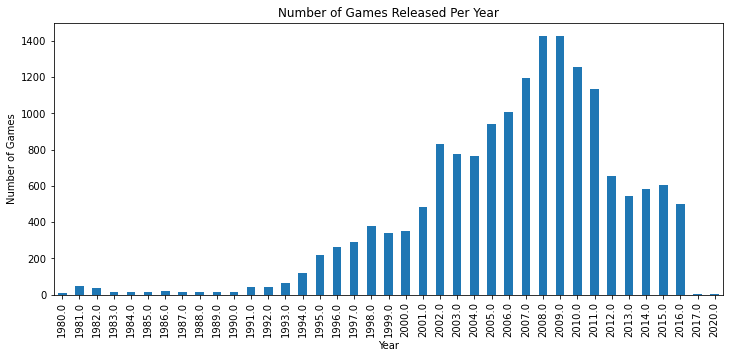

In [11]:
# Number of Games Released per Year

games_per_year = df['Year_of_Release'].value_counts().sort_index()

plt.figure(figsize=(12,5))
games_per_year.plot(kind='bar')
plt.title("Number of Games Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.show()

📊 The number of games released grew steadily from the 1990s, peaked around 2008–2009, then declined and this explains why older games lack critic/user reviews and why missingness is NOT random.

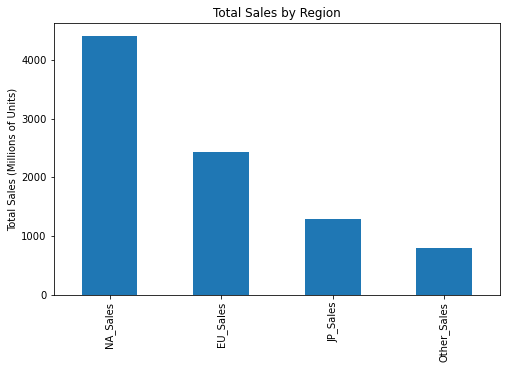

In [12]:
# Total Sales by Region

region_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Total Sales by Region")
plt.ylabel("Total Sales (Millions of Units)")
plt.show()

📊 North America and Europe dominate total game sales, while Japan and other regions contribute much less, showing that gaming markets differ strongly by region.

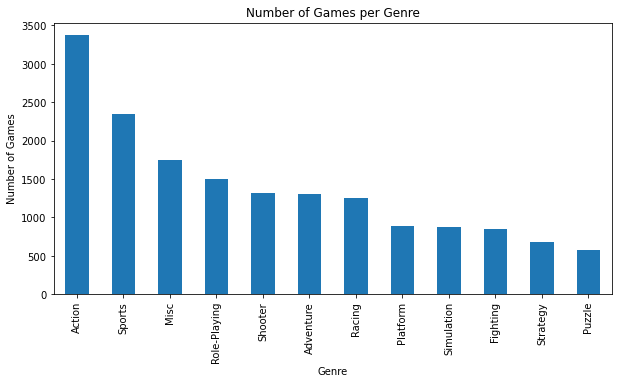

In [15]:
# Number of Games per Genre

plt.figure(figsize=(10,5))
df['Genre'].value_counts().plot(kind='bar')
plt.title("Number of Games per Genre")
plt.ylabel("Number of Games")
plt.xlabel("Genre")
plt.show()

📊 The industry produces far more Action games than any other genre, while genres like Puzzle and Strategy are niche, making genre comparisons highly imbalanced.

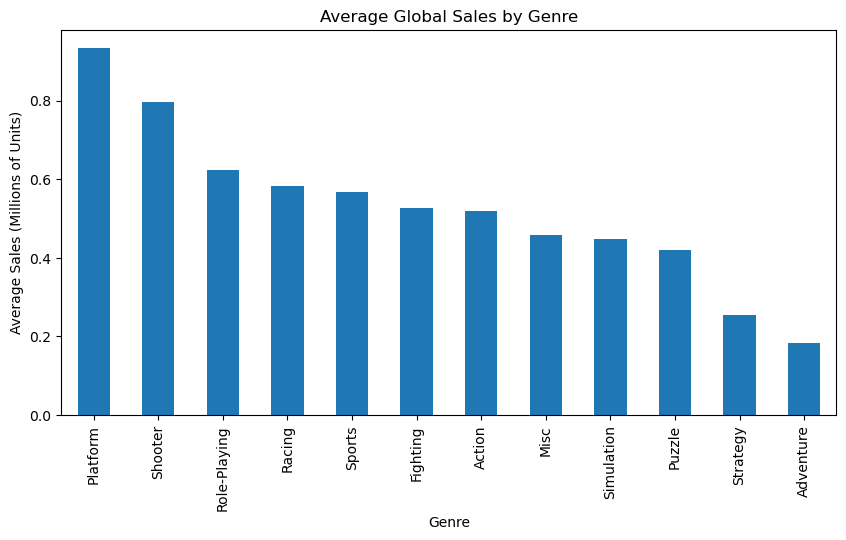

In [27]:
# Average Sales by Genre 

avg_sales_by_genre = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
avg_sales_by_genre.plot(kind='bar')
plt.title("Average Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Sales (Millions of Units)")
plt.show()

📊 Platform and Shooter games achieve the highest average sales per title, while Adventure, Strategy, and Puzzle games sell the least on average.

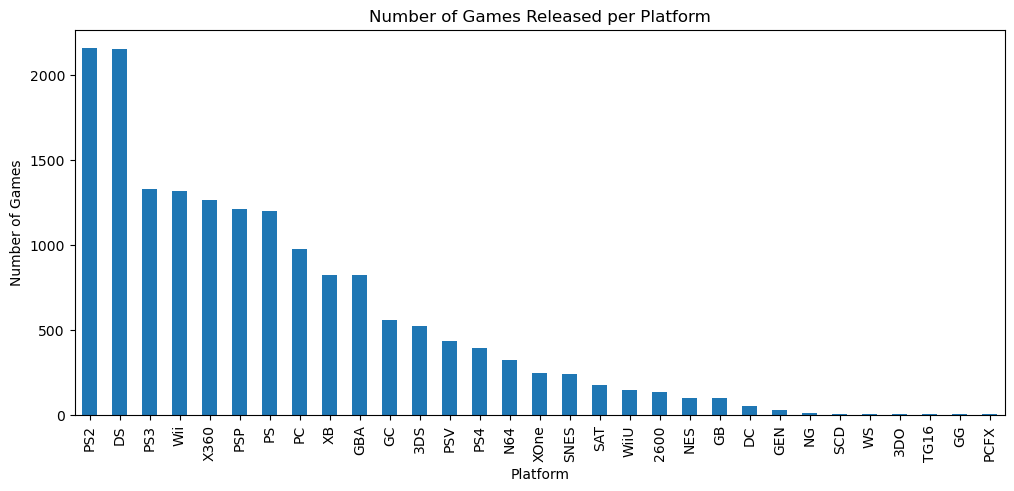

In [29]:
# Number of Games per Platform 

plt.figure(figsize=(12,5))
df['Platform'].value_counts().plot(kind='bar')
plt.title("Number of Games Released per Platform")
plt.ylabel("Number of Games")
plt.xlabel("Platform")
plt.show()

📊 PS2 and DS dominate in number of released games, reflecting their huge popularity.

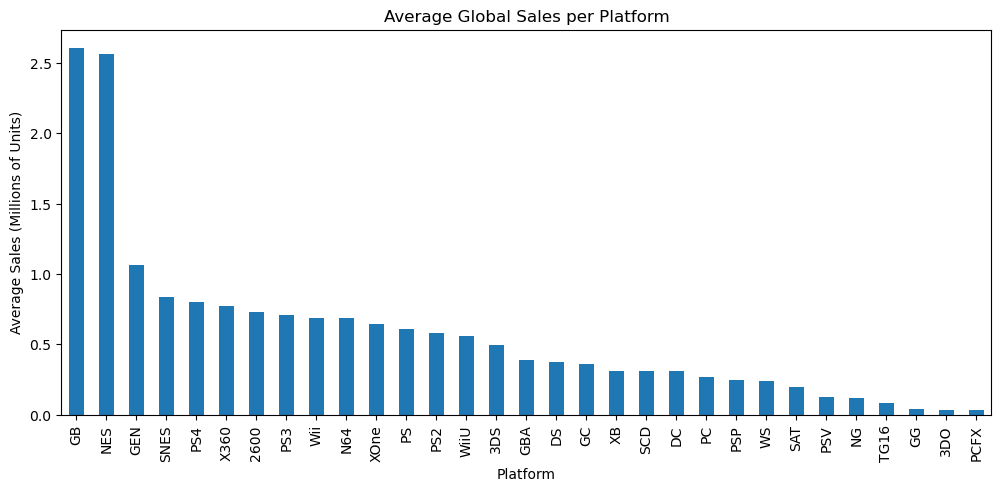

In [31]:
# Average Global Sales by Platform 

avg_sales_by_platform = df.groupby('Platform')['Global_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
avg_sales_by_platform.plot(kind='bar')
plt.title("Average Global Sales per Platform")
plt.ylabel("Average Sales (Millions of Units)")
plt.xlabel("Platform")
plt.show()

📊 Older Nintendo platforms (GB, NES, GEN) have the highest average game sales because they have fewer titles and many iconic bestsellers, while modern and handheld platforms have lower averages due to market saturation and smaller hit ratios.

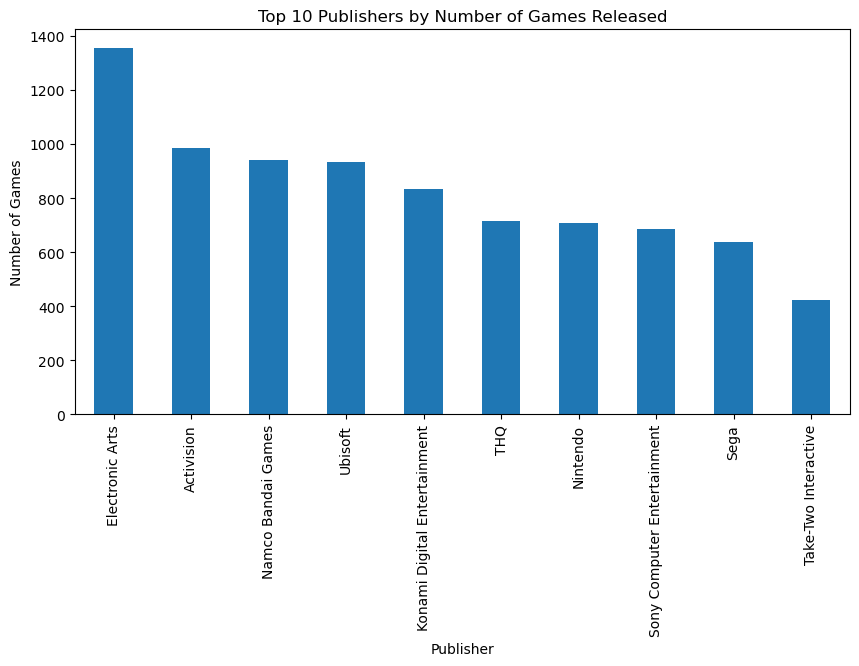

In [33]:
# Top Publishers by Number of Games Released

top_publishers_count = df['Publisher'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_publishers_count.plot(kind='bar')
plt.title("Top 10 Publishers by Number of Games Released")
plt.ylabel("Number of Games")
plt.show()

📊 EA and Activision release the most games, but Nintendo dominates total sales thanks to fewer but extremely successful franchises, proving that sales quality matters more than quantity.

# ⭐Inferential Statistics

### 🔹 T-test: High vs Low Critic Score

In [35]:
median_cs = df["Critic_Score"].replace(0, np.nan).median()

high_cs = df[df["Critic_Score"] >= median_cs]["Global_Sales"]
low_cs  = df[df["Critic_Score"] <  median_cs]["Global_Sales"]

t_stat, p_val = ttest_ind(high_cs, low_cs, equal_var=False)
print("Critic Score vs Sales p-value:", p_val)

Critic Score vs Sales p-value: 1.3423873603989951e-73


### 🔹 T-test: Action vs Non-Action

In [37]:
action_sales     = df[df["Genre"] == "Action"]["Global_Sales"]
non_action_sales = df[df["Genre"] != "Action"]["Global_Sales"]

t_stat, p_val = ttest_ind(action_sales, non_action_sales, equal_var=False)
print("Action vs Non-Action p-value:", p_val)

Action vs Non-Action p-value: 0.4191686932707518


### 🔹 T-test: Before vs After 2005 (Critic_Count)

In [39]:
old_games = df[df["Year_of_Release"] < 2005]["Critic_Count"]
new_games = df[df["Year_of_Release"] >= 2005]["Critic_Count"]

t_stat, p_val = ttest_ind(new_games, old_games, equal_var=False)
print("Before vs After 2005 p-value:", p_val)

Before vs After 2005 p-value: nan


### 🔹 T-test: Nintendo vs Others

In [41]:
nintendo = df[df["Publisher"] == "Nintendo"]["Global_Sales"]
others   = df[df["Publisher"] != "Nintendo"]["Global_Sales"]

t_stat, p_val = ttest_ind(nintendo, others, equal_var=False)
print("Nintendo vs Others p-value:", p_val)

Nintendo vs Others p-value: 1.5110395388781601e-21


# 💻 Data Preprocessing

### ✅ STEP 1 — We will drop Non-Useful Columns

### Why?

These columns either add noise, have too many missing values, or are irrelevant for prediction:

**Name** → text, no predictive power

**Developer** → 40% missing, 1700 categories

**Rating** → inconsistent, 40% missing

**User_Score** → messy + weak correlation

In [43]:
df = df.drop(columns=["Name", "Developer", "Rating", "User_Score"])

# Show the resulting table
df.head()

,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
0,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,322.0
1,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN
2,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,709.0
3,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,192.0
4,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN


### ✅ STEP 2 — Fix Data Types
### Specifically:

**Year** must be integer

Convert **Critic/User counts** to numeric

In [45]:
df["Year_of_Release"] = df["Year_of_Release"].fillna(0).astype(int)

df["Critic_Score"] = pd.to_numeric(df["Critic_Score"], errors="coerce") 
df["Critic_Count"] = pd.to_numeric(df["Critic_Count"], errors="coerce")
df["User_Count"] = pd.to_numeric(df["User_Count"], errors="coerce")

# Show the resulting table
df.head() # we can see that Year_of_Release column coverted from float to integer 

,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
0,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,322.0
1,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN
2,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,709.0
3,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,192.0
4,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN


### ✅ STEP 3 — Handle Missing Values
 **EDA showed:**
 - Missing values in Critic/User scores/counts are NOT random
  (older games were released before review aggregation websites existed).
 - Publisher and Genre contain some missing entries.

**Strategy:**
 -  Fill Critic/User missing values with 0  (meaning "No reviews")
 -  Fill Publisher and Genre missing values with "Unknown"

### 🔍 1. Display table of missing values BEFORE filling

In [47]:
df_before = df.copy()
print("📌 Missing values BEFORE filling:")
print()
display(df_before.isna().sum())


📌 Missing values BEFORE filling:



Platform              0
Year_of_Release       0
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Count         9129
dtype: int64

### 🔄 2. Convert Critic/User columns to numeric (ensure proper dtype)
       Any 'tbd' or invalid values will become NaN via errors='coerce'

In [49]:
# Convert critic/user columns to numeric
df["Critic_Score"] = pd.to_numeric(df["Critic_Score"], errors="coerce")
df["Critic_Count"] = pd.to_numeric(df["Critic_Count"], errors="coerce")
df["User_Count"] = pd.to_numeric(df["User_Count"], errors="coerce")


### 🧹 3. Fill missing values
   - Review numbers → fill with 0 (no reviews)
   - Categorical variables → fill with "Unknown"

In [51]:
# Filling columns with missing values
df["Critic_Score"] = df["Critic_Score"].fillna(0)
df["Critic_Count"] = df["Critic_Count"].fillna(0)
df["User_Count"] = df["User_Count"].fillna(0)
df["Publisher"] = df["Publisher"].fillna("Unknown")
df["Genre"] = df["Genre"].fillna("Unknown")


### ✔️ 4. Display table of missing values AFTER filling

In [53]:
print("📌 Missing values AFTER filling:")
display(df.isna().sum())

📌 Missing values AFTER filling:


Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Count         0
dtype: int64

### ✅ STEP 4 — Encode Categorical Variables
**Required for:**<br>
   • PCC feature selection<br>
   • Random Forest<br>
   • Support Vector Regression (numeric-only input)<br>

**Categorical columns:**<br>
  1- Platform<br>
  2- Genre<br>
  3- Publisher<br>

In [55]:
print("\n🔢 Number of columns BEFORE encoding:", len(df.columns))


🔢 Number of columns BEFORE encoding: 12


In [57]:

cat_cols = ["Platform", "Genre", "Publisher"]


### 🔍 1. Show the categorical columns BEFORE encoding

In [59]:
print("📌 Categorical columns BEFORE encoding:\n")
print(df[cat_cols].dtypes)
display(df[cat_cols].head())

📌 Categorical columns BEFORE encoding:

Platform     object
Genre        object
Publisher    object
dtype: object


,Platform,Genre,Publisher
0,Wii,Sports,Nintendo
1,NES,Platform,Nintendo
2,Wii,Racing,Nintendo
3,Wii,Sports,Nintendo
4,GB,Role-Playing,Nintendo


### 📊 2. Visualize number of unique categories (optional but helpful)

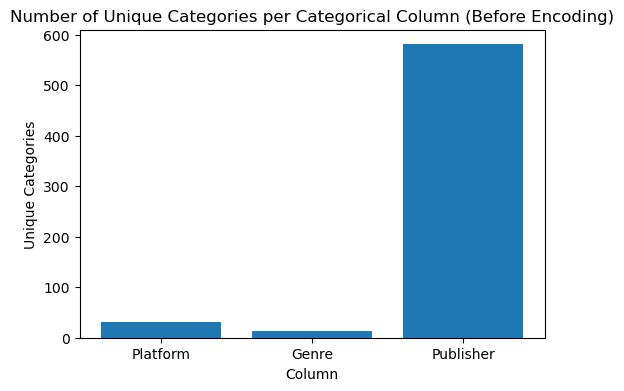

In [61]:
unique_counts = df[cat_cols].nunique()

plt.figure(figsize=(6,4))
plt.bar(unique_counts.index, unique_counts.values)
plt.title("Number of Unique Categories per Categorical Column (Before Encoding)")
plt.xlabel("Column")
plt.ylabel("Unique Categories")
plt.show()

### 3.1 Frequency Encoding for Platform

Replaces each category with how often it appears in the dataset.

**Why?** Platform has 31 categories → too large for one-hot.


In [63]:
if "Platform" in df.columns:
    platform_freq = df["Platform"].value_counts()
    df["Platform_FE"] = df["Platform"].map(platform_freq)


### 3.2 One-Hot Encoding for Genre

Creates a new binary column for each category.

**Why?** Genre has only 12 categories & Genre differences are meaningful.

In [65]:
if "Genre" in df.columns:
    df = pd.get_dummies(df, columns=["Genre"], drop_first=True)


### 3.3 Target Encoding for Publisher

Replaces each category with the average target value (e.g., log sales) for that category.

**Why?** Publisher has 581 categories → impossible for one-hot & Average sales per publisher is a strong signal

In [67]:
# Manual target encoding for Publisher
publisher_means = df.groupby("Publisher")["Global_Sales"].mean()

df["Publisher_TE"] = df["Publisher"].map(publisher_means)



In [69]:
print("\n🔢 Number of columns AFTER encoding:", len(df.columns))


🔢 Number of columns AFTER encoding: 25


### 🔎 4. Show a preview of dummy columns

In [71]:
dummy_cols = [c for c in df.columns 
              if c.startswith("Platform_") 
              or c.startswith("Genre_") 
              or c.startswith("Publisher_")]

print("\n📌 Sample of dummy columns AFTER encoding (first 10 columns):")
display(df[dummy_cols[:10]].head())



📌 Sample of dummy columns AFTER encoding (first 10 columns):


,Platform_FE,Genre_Adventure,Genre_Fighting,Genre_Misc,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role-Playing,Genre_Shooter,Genre_Simulation
0,1320,False,False,False,False,False,False,False,False,False
1,98,False,False,False,True,False,False,False,False,False
2,1320,False,False,False,False,False,True,False,False,False
3,1320,False,False,False,False,False,False,False,False,False
4,98,False,False,False,False,False,False,True,False,False


### 📊 5. Summary table — Number of dummy columns for each original category

In [73]:
platform_dummies  = [c for c in df.columns if c.startswith("Platform_")]
genre_dummies     = [c for c in df.columns if c.startswith("Genre_")]
publisher_dummies = [c for c in df.columns if c.startswith("Publisher_")]

summary = {
    "Original Column": ["Platform", "Genre", "Publisher"],
    "Number of Dummy Columns": [
        len(platform_dummies),
        len(genre_dummies),
        len(publisher_dummies)
    ]
}

summary_df = pd.DataFrame(summary)
display(summary_df)

,Original Column,Number of Dummy Columns
0,Platform,1
1,Genre,12
2,Publisher,1


### ✅ STEP 5 — Add Log-Transformed Target Variable

**Global_Sales is highly skewed** → log-transform helps:
  - Reduce skewness
  - Improve model stability & performance
  - Make relationships more linear

   Using log1p(x) = log(1 + x) → avoids issues with zeros.

 ### 🔄 1. Create the log-transformed target column  

In [75]:
df["Log_Global_Sales"] = np.log1p(df["Global_Sales"])   # log(1 + x)

### 🔍 2. Preview target before and after transformation

In [77]:
print("📌 Preview of target before and after log transform:\n")
display(df[["Global_Sales", "Log_Global_Sales"]].head())

📌 Preview of target before and after log transform:



,Global_Sales,Log_Global_Sales
0,82.53,4.425206
1,40.24,3.719409
2,35.52,3.597860
3,32.77,3.519573
4,31.37,3.477232


### 📊 3. Plot distributions before & after transformation

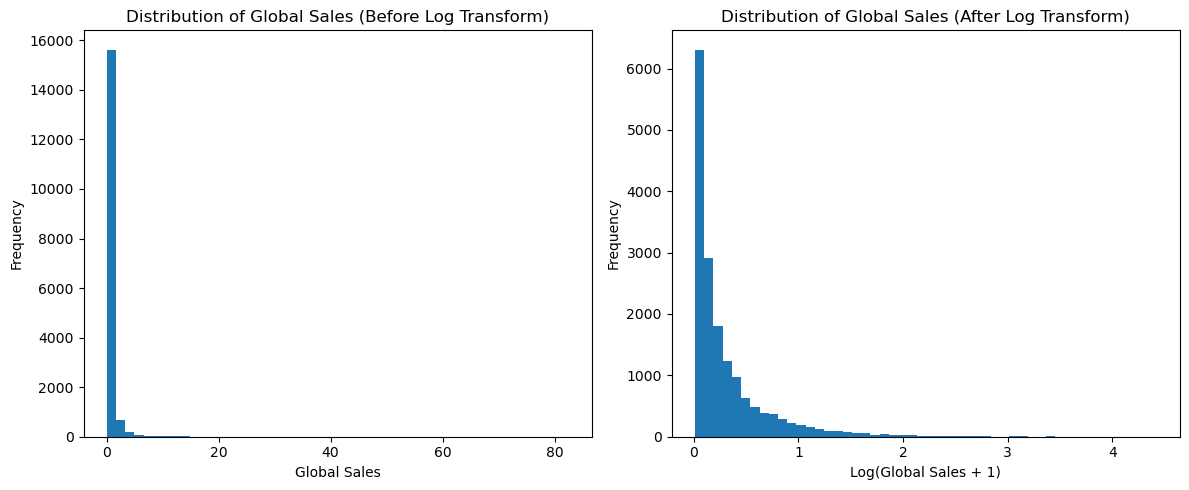

In [79]:
plt.figure(figsize=(12,5))

# ----- Before log transform -----
plt.subplot(1, 2, 1)
plt.hist(df["Global_Sales"], bins=50)
plt.title("Distribution of Global Sales (Before Log Transform)")
plt.xlabel("Global Sales")
plt.ylabel("Frequency")

# ----- After log transform -----
plt.subplot(1, 2, 2)
plt.hist(df["Log_Global_Sales"], bins=50)
plt.title("Distribution of Global Sales (After Log Transform)")
plt.xlabel("Log(Global Sales + 1)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# 💻 Model Implementation and Analysis

### Split Into Features (X) and Target (y) 

**Goal:**
- X = FINAL SELECTED FEATURES (PCC + RFFS)
- y = log-transformed target (Log_Global_Sales)

### Define Features (X) and Target (y)

In [81]:
# Drop both original and log target from X, keep only predictors
X = df.drop(columns=["Global_Sales", "Log_Global_Sales"])

In [83]:
# Target = log-transformed global sales
y = df["Log_Global_Sales"]

print("📌 Features (X) preview BEFORE train/test split:")
display(X.head())

print("\n📌 Target (y) preview:")
display(y.head())

📌 Features (X) preview BEFORE train/test split:


,Platform,Year_of_Release,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Critic_Score,Critic_Count,User_Count,...,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role-Playing,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy,Genre_Unknown,Publisher_TE
0,Wii,2006,Nintendo,41.36,28.96,3.77,8.45,76.0,51.0,322.0,...,False,False,False,False,False,False,True,False,False,2.533725
1,NES,1985,Nintendo,29.08,3.58,6.81,0.77,0.0,0.0,0.0,...,True,False,False,False,False,False,False,False,False,2.533725
2,Wii,2008,Nintendo,15.68,12.76,3.79,3.29,82.0,73.0,709.0,...,False,False,True,False,False,False,False,False,False,2.533725
3,Wii,2009,Nintendo,15.61,10.93,3.28,2.95,80.0,73.0,192.0,...,False,False,False,False,False,False,True,False,False,2.533725
4,GB,1996,Nintendo,11.27,8.89,10.22,1.00,0.0,0.0,0.0,...,False,False,False,True,False,False,False,False,False,2.533725



📌 Target (y) preview:


0    4.425206
1    3.719409
2    3.597860
3    3.519573
4    3.477232
Name: Log_Global_Sales, dtype: float64

In [85]:
# Drop raw categorical columns (keep only encoded versions)
X = X.select_dtypes(include=[np.number])

###  📌 Feature Selection (PCC + Random Forest)

In [87]:
# 1. PCC Feature Selection (Aligned with X and y)

# Step 1 — get the numeric predictors ONLY (same columns used in X)
numeric_predictors = X.select_dtypes(include=[np.number]).copy()

# Step 2 — add the target column temporarily to compute correlation
temp_df = numeric_predictors.copy()
temp_df["Log_Global_Sales"] = y

# Step 3 — compute correlation
corr = temp_df.corr()

# Step 4 — correlation values for target
target_corr = corr["Log_Global_Sales"].sort_values(ascending=False)

print("\n===== PCC: Correlation with Log_Global_Sales =====")
print(target_corr)

# Step 5 — select features with |corr| ≥ 0.10
selected_pcc = target_corr[abs(target_corr) >= 0.10].index.tolist()

# Remove target itself
if "Log_Global_Sales" in selected_pcc:
    selected_pcc.remove("Log_Global_Sales")

print("\nSelected by PCC:", selected_pcc)



===== PCC: Correlation with Log_Global_Sales =====
Log_Global_Sales    1.000000
NA_Sales            0.735785
EU_Sales            0.715041
Other_Sales         0.610893
JP_Sales            0.501362
Publisher_TE        0.442800
Critic_Count        0.377623
User_Count          0.290031
Critic_Score        0.258429
Year_of_Release     0.012721
Platform_FE        -0.031839
Name: Log_Global_Sales, dtype: float64

Selected by PCC: ['NA_Sales', 'EU_Sales', 'Other_Sales', 'JP_Sales', 'Publisher_TE', 'Critic_Count', 'User_Count', 'Critic_Score']


In [89]:
# 2. Random Forest Feature Selection (RFFS)

# same X, y as above
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train_fs, y_train_fs)

importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\n===== Random Forest Feature Importances =====")
print(importance_df.head(20))

# select features importance ≥ 0.01
selected_rffs = importance_df[importance_df["Importance"] >= 0.01]["Feature"].tolist()

print("\nSelected by RFFS:", selected_rffs)


===== Random Forest Feature Importances =====
           Feature  Importance
1         NA_Sales    0.737290
2         EU_Sales    0.103520
4      Other_Sales    0.093758
3         JP_Sales    0.063338
0  Year_of_Release    0.000408
7       User_Count    0.000387
9     Publisher_TE    0.000369
5     Critic_Score    0.000358
8      Platform_FE    0.000295
6     Critic_Count    0.000276

Selected by RFFS: ['NA_Sales', 'EU_Sales', 'Other_Sales', 'JP_Sales']


In [91]:
selected_final = set(selected_pcc).union(selected_rffs)

print("\n===== FINAL SELECTED FEATURES (PCC + RFFS) =====")
print(selected_final)



===== FINAL SELECTED FEATURES (PCC + RFFS) =====
{'JP_Sales', 'Publisher_TE', 'Critic_Score', 'EU_Sales', 'Critic_Count', 'User_Count', 'Other_Sales', 'NA_Sales'}


###  📌 Predictive Modeling Using Support Vector Regression

### Apdate selected Features (X) and Target (y) + Train/Test Split

**Goal:**
- X = FINAL SELECTED FEATURES (PCC + RFFS)
- y = log-transformed target (Log_Global_Sales)
- Split data into Training and Test sets (80% / 20%)

### 1️⃣ Define Features (X) and Target (y)


In [93]:
selected_final = [
    'JP_Sales', 'Publisher_TE', 'Critic_Score', 'EU_Sales', 'Critic_Count', 'User_Count', 'Other_Sales', 'NA_Sales'
]

In [95]:
X = df[selected_final]
y = df["Log_Global_Sales"]

### 2️⃣ Train/Test Split

In [97]:
# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Scale Numeric Features (Required for SVR)
### 📊 Identify numeric columns

In [99]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
print("Number of numeric columns to scale:", len(numeric_cols))
display(pd.DataFrame(numeric_cols, columns=["Numeric Columns"]))

Number of numeric columns to scale: 8


,Numeric Columns
0,JP_Sales
1,Publisher_TE
2,Critic_Score
3,EU_Sales
4,Critic_Count
5,User_Count
6,Other_Sales
7,NA_Sales


### 🔧 Apply StandardScaler

In [101]:
# Create copies of data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform test data
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling completed successfully.")


Scaling completed successfully.


In [103]:
# Configure SVR model
# ---------------------------------------
svr_model = SVR(
    kernel="rbf",       # The RBF kernel enables the model to learn nonlinear relationships.
    C=50.0,             # This parameter controls the trade-off between model simplicity and error tolerance.
    gamma=0.001,         # Gamma determines how far the influence of a single training sample extends.
    epsilon=0.01         # Epsilon defines the width of the ε-insensitive tube, where prediction errors smaller than ε are ignored.
)

In [105]:
# Train the model
# ---------------------------------------
svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,0.001
,coef0,0.0
,tol,0.001
,C,50.0
,epsilon,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [107]:
# Make predictions
# ---------------------------------------
y_pred = svr_model.predict(X_test_scaled)

In [109]:
# Evaluate model
# ---------------------------------------
r2 = r2_score(y_test, y_pred)

print("===== SVR Model Evaluation =====")
print("R² Score:", r2)

===== SVR Model Evaluation =====
R² Score: 0.8283961821663423


### 🎉 Amazing result! This is excellent performance, especially for a real-world noisy dataset like video game sales.